Before you submit this problem, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as your name below:

In [ ]:
NAME = "Michel Jean Joseph Donnet"

In [1]:
import IPython
assert IPython.version_info[0] >= 3, "Your version of IPython is too old, please update it."

---

In [2]:
import matplotlib.pyplot as plt
from PIL import Image
import skimage
from skimage.io import imread
from skimage.color import rgb2gray
import numpy as np
import cv2

---
## Part A, reading the images (3 points)

Write a function that reads an image from the path and returns as numpy array. Note that tangled.jpg is a 3-channel color image with 4th alpha channel.

In [3]:
def read_image_pillow(path) -> np.ndarray:
    """read an image and return as numpy array"""
    # YOUR CODE HERE
    
    img = Image.open(path)
    return np.array(img)

You function should return the image with shape equal to `(1080, 1920, 3)`

In [6]:
read_image_pillow("tangled.jpg").shape

(1080, 1920, 3)

In [7]:
assert read_image_pillow("tangled.jpg").shape == (1080, 1920, 3)

#### Write a function that reads an image from the path and returns as numpy array

In [8]:
def read_image_skimage(path) -> np.ndarray:
    """read an image and return as numpy array"""
    # YOUR CODE HERE
    img = imread(path)
    return img

You function should return the image with shape equal to `(1080, 1920, 3)`

(1080, 1920, 3)


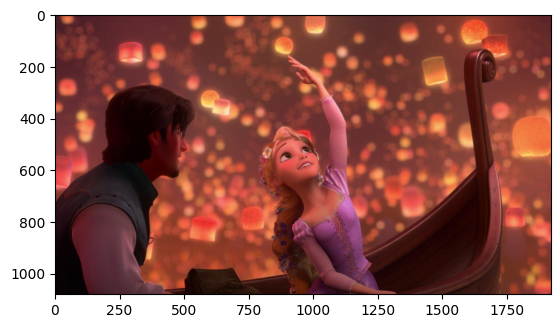

In [9]:
x = read_image_skimage("tangled.jpg")
print(x.shape)
plt.imshow(x)

In [10]:
assert read_image_skimage("tangled.jpg").shape == (1080, 1920, 3)

#### Write a function that reads an image from the path and returns as numpy array. Make sure that the resulting color channels are in Red-Green-Blue order.

In [11]:
def read_image_opencv(path) -> np.ndarray:
    """read an image and return as numpy array"""
    # YOUR CODE HERE
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

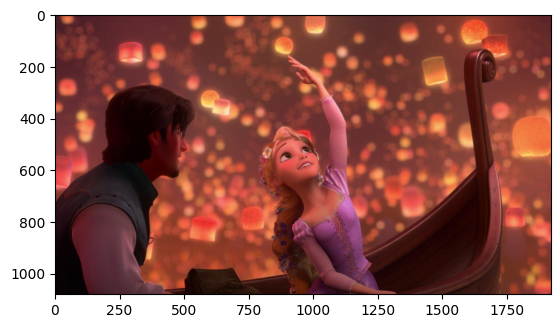

In [12]:
x = read_image_opencv("tangled.jpg")
plt.imshow(x)

In [13]:
assert read_image_opencv("tangled.jpg").shape == (1080, 1920, 3)

#### In the end your 3 different implementations must yield the same results

In [14]:
np.testing.assert_equal(
    read_image_pillow("tangled.jpg"),
    read_image_skimage("tangled.jpg"),
    read_image_opencv("tangled.jpg"),
)

---

## Part B, the image representation, datatypes, channels (2 points)

Starting from here, it is crucial to understand how the image is represented in 99% of computer science applications.  
The first point was to read it, yes. Now we need to work with it. And to know what are we working is a half of success in the actual work.  
As we have seen already each image has its shape. In case of tangled.jpg it has ```(1080, 1920, 3)```. Each image has a form of ```(x, y, z)``` (in OpenCV), or in case of NumPy it's ```(y, x, z)```. Note that the NumPy variant is dominant and even if working with OpenCV functions, they still operate with NumPy arrays.  
As you might have guess, __x__ denotes the width, __y__ -  the height and __z__ - number of channels (or depth). Quite often the image can have only 1 channel (grayscale), then it may come in a form of either ```(y, x)``` or ```(y, x, z=1)```.

Okay to much words, let's see how does it work in practice by example.  
The operations used below are called slicing or indexing and if you are not familiar with them  [have a look at the manual](https://numpy.org/doc/stable/user/basics.indexing.html).

Text(0.5, 1.0, 'Selecting only each 6th row and each 6th col')

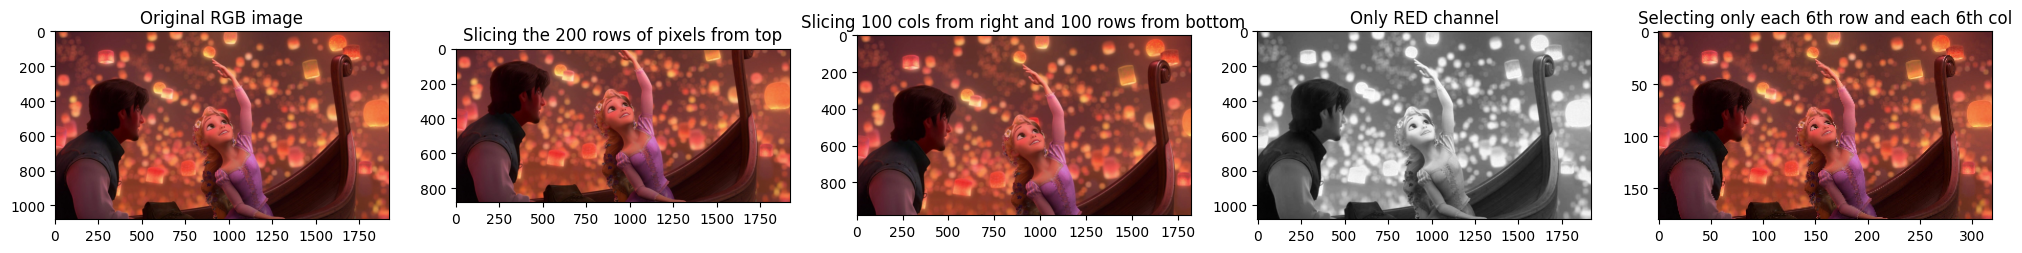

In [15]:
fig, axs = plt.subplots(1, 5, figsize=(25, 7))
axs[0].imshow(x)
axs[0].set_title("Original RGB image")
axs[1].imshow(x[200:, :])
axs[1].set_title("Slicing the 200 rows of pixels from top")

axs[2].imshow(x[:-100, :-100])
axs[2].set_title("Slicing 100 cols from right and 100 rows from bottom")

axs[3].imshow(x[:, :, 0], cmap="gray")
axs[3].set_title("Only RED channel")

axs[4].imshow(x[::6, ::6])
axs[4].set_title("Selecting only each 6th row and each 6th col")

Practically speaking, since the images are a form of matrices from linear algebra you can perform any sort of linear operation on them.

Average intensity of whole image = 77.96
Average intensity of red channel = 126.25
Average intensity of green channel = 58.58
Average intensity of blue channel = 49.06


Text(0.5, 1.0, 'Previos operations in float32')

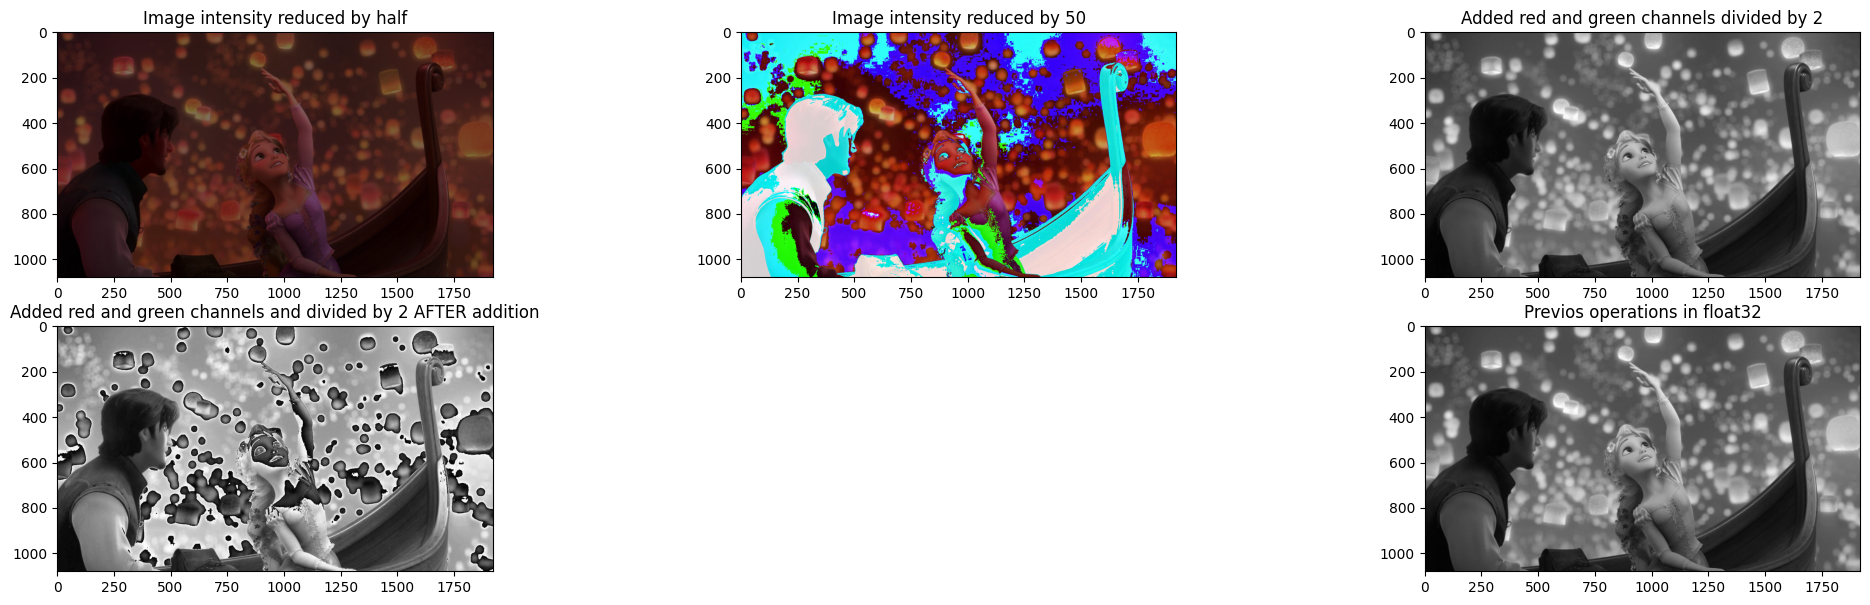

In [16]:
print(f"Average intensity of whole image = {x.mean():.2f}")
print(f"Average intensity of red channel = {x[:, :, 0].mean():.2f}")
print(f"Average intensity of green channel = {x[:, :, 1].mean():.2f}")
print(f"Average intensity of blue channel = {x[:, :, 2].mean():.2f}")

fig, axs = plt.subplots(2, 3, figsize=(25, 7))
axs[0, 0].imshow(x // 2)
axs[0, 0].set_title("Image intensity reduced by half")

axs[0, 1].imshow(x - 50)
axs[0, 1].set_title("Image intensity reduced by 50")

axs[0, 2].imshow(x[:, :, 0] // 2 + x[:, :, 1] // 2, cmap="gray")
axs[0, 2].set_title("Added red and green channels divided by 2")

axs[1, 0].imshow((x[:, :, 0] + x[:, :, 1]) // 2, cmap="gray")
axs[1, 0].set_title("Added red and green channels and divided by 2 AFTER addition")

axs[1,1].remove()

axs[1, 2].imshow(
    (x[:, :, 0].astype(np.float32) + x[:, :, 1].astype(np.float32)) // 2, cmap="gray"
)
axs[1, 2].set_title("Previos operations in float32")

Note the plot #2 as we see the artifacts produced by bit overflow. This is caused by the fact that as for now the image has a type of uint8, unsigned integer with 8 bits. Unsigned means that pixel in this image cannot have a value below 0. Everythin what goes below 0 becomes a positive integer again, starting from top of range which is ```2^8-1=255```. As you can see only green color in these artifacts it means that this channel has many values below 50, so after subtracting 50 from original image the pixels in green channel overflow.  
In plot #4 you can see how the order of operations produces bit overflow again.  
And in plot #5 we overcome this problem by firsly converting the uint8 images to float32, which is a signed type and doesn't have the bit overflow problems as uint8 does.

#### Here you should implement the min-max normalization.  
The min-max normalization consists of the following steps:
1. Find the minimum and maximum values of the image
2. Subtract the minimum from the image
3. Divide by the (maximum - minimum)
4. Return the result

Note that the function should return the normalized image as float32.

In [17]:
def minmax_norm(x):
    # YOUR CODE HERE
    x_min = x.min()
    x_max = x.max()
    return (x - x_min) / (x_max - x_min)

In [18]:
assert type(minmax_norm(x)) == np.ndarray

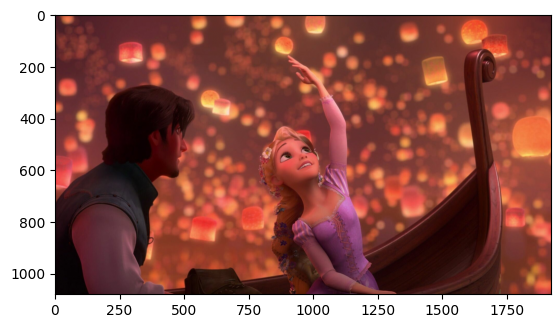

In [19]:
plt.imshow(minmax_norm(x))

#### As you can see, visually the results are the same, but the data type and the values range are different.

#### Now let's proceed with some basics. Implement the following function, which does:
0. Convert image to float32
1. Divide the image by 2
2. Add 50 to all channels
3. Subtract 30 from the red channel
4. Apply previously implemented min-max normalization
6. Multiply by 255
7. Convert to uint8
8. Return the image

In [20]:
def process_image(x):
    x = x.astype(np.float32)
    x += 50
    x[:, :, 0] -= 30
    x = minmax_norm(x)
    x = (x * 255).astype(np.uint8)
    return x

In [21]:
assert type(process_image(x)) == np.ndarray

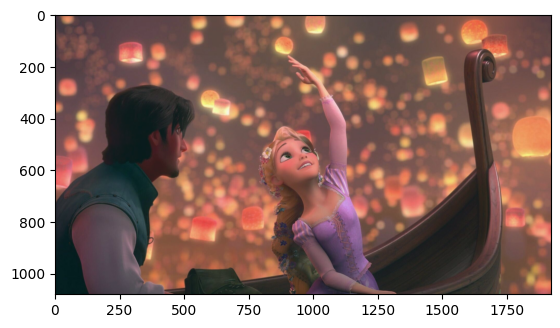

In [22]:
plt.imshow(process_image(x))

---
## Part C, converting images to different color spaces (2 points)

Starting this part you probably had solved the issue while implementing OpenCV image read function since OpenCV treats images in a different way by switching the places of Red and Blue channels.  
This gives you a hint that a second color space after RGB which we may work with is BGR.
On top of them there are plenty of others.  
Let's start with a simple example of HSV which denotes as **H**ue **S**aturation **V**alue.

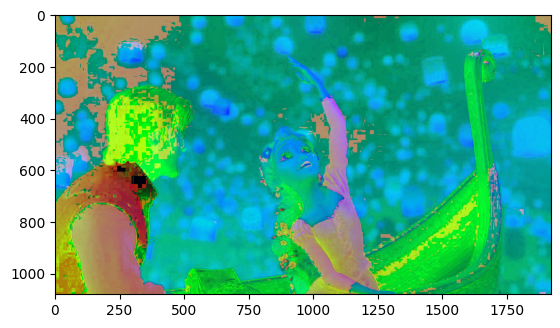

In [23]:
x_hsv = cv2.cvtColor(x, cv2.COLOR_RGB2HSV)
plt.imshow(x_hsv)

As you can see, displaying this picture in a usual way (which is most suited to represent RGB images) yields an awfully unrecognasible image.
What's the use case you may ask?  
Well, it depends on the task :)  
For example, when we definitely do not care about color components of the image and are interested only in its intensity/brightness the **V** channel gives us this opportunity.  
See the example below. 

Text(0.5, 1.0, 'Value')

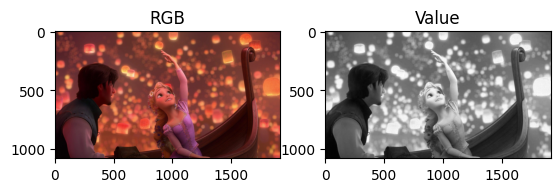

In [24]:
fig, axs = plt.subplots(1, 2)

axs[0].imshow(x)
axs[0].set_title("RGB")
axs[1].imshow(x_hsv[:, :, -1], cmap="gray")
axs[1].set_title("Value")

#### Write a function which converts RGB image to grayscale using OpenCV

In [25]:
def rgb2gray_opencv(img):
    """convert an RGB image to grayscale"""
    # YOUR CODE HERE
    img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return img_gray

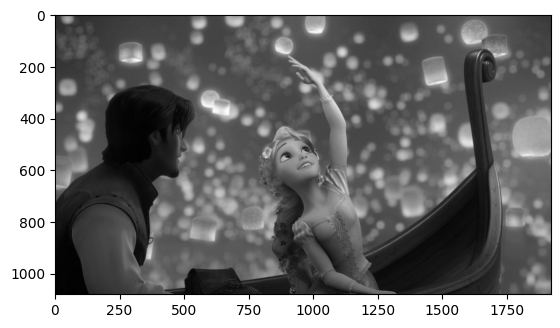

In [26]:
plt.imshow(rgb2gray_opencv(read_image_opencv("tangled.jpg")), cmap="gray")

In [27]:
assert type(rgb2gray_opencv(np.zeros((10, 10, 3), dtype=np.uint8))) == np.ndarray 

---
## Part D, calculating histograms (2 points)

Now let's proceed with calculating a histogram of the image. Given that most of the images with which we will be working are multi-channel it's possible to compute a histogram per channel.  
As seen in the example below we show the way to do it using NumPy and plotting it.

In [28]:
def calc_histogram_numpy(x):
    """
    calculate the histograms of image with any amount of channels

    """
    hists = [
        np.histogram(x[:, :, c], bins=256, range=(0, 255))[0] for c in range(x.shape[2])
    ]
    return hists

In [29]:
def plot_histograms(hists, title, channels=None):
    """
    plot histograms using matplotlib, by default it expects RGB as an input
    change channels paramter to meet the other amount of channels
    """

    plt.figure()
    plt.title(title)
    channels = channels or ["red", "green", "blue"]

    for hist, channel in zip(hists, channels):
        plt.plot(hist, label=channel, linestyle="-", color=channel)
    plt.show()

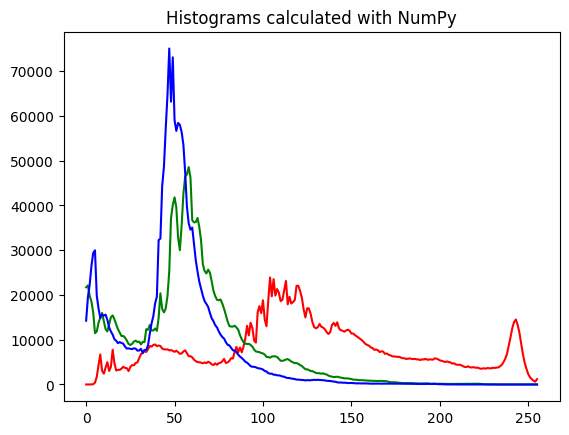

In [30]:
x = read_image_skimage("tangled.jpg")
hists = calc_histogram_numpy(x)
plot_histograms(hists, "Histograms calculated with NumPy")

#### Implement here the histogram calculation using OpenCV

You can verify your solution by comparing the results with the ones obtained using NumPy.

In [31]:
def calc_histogram_opencv(x):
    """
    calculate the histograms of image with any amount of channels using OpenCV

    """
    hists = [cv2.calcHist([x], [c], None, [256], [0, 255]).flatten() for c in range(x.shape[2])]

    return hists

In [32]:
assert type(calc_histogram_opencv(np.zeros((10, 10, 3), dtype=np.uint8))[0]) == np.ndarray 

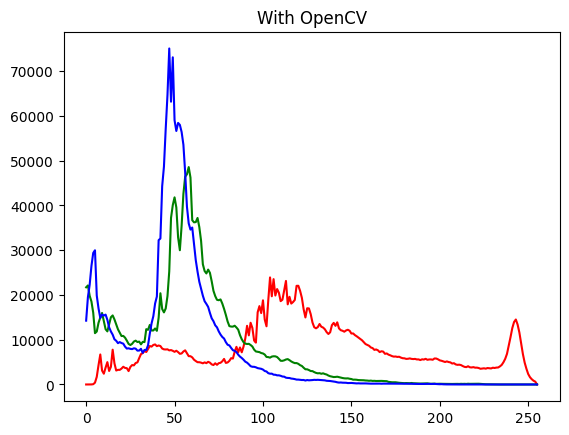

In [33]:
hists = calc_histogram_opencv(x)
plot_histograms(calc_histogram_opencv(x), "With OpenCV")

---
## Part E, binarization/thresholding (2 points)

#### Both the binarization and the thresholding are roughly the same things in the context of image processing, at least for now. We will use the term "binarization" from now on.
The binarization is a process of converting the image to a binary form. This means that each pixel in the image is converted to either 0 or 1. In uint8 images this means that the pixel is either 0 or 255.  
Using NumPy it's quite easy to do.  
You can do it in two different ways.
1. Using the for loops.
2. Using the vectorized operations.


Both of them have the different purposes and the different execution speed.

Let's start with the example.

In [34]:
def binarize_image_loop(x, t):
    """
    The function binarizes the red channel of the image using the threshold t.

    Args:
        x : image
        t : threshold value
    """
    r = (
        x[:, :, 0].copy()
    )  ## we need to make a copy of the red channel to avoid changing the original image
    h, w = r.shape
    for i in range(h):
        for j in range(w):
            if r[i, j] > t:
                r[i, j] = 255
            else:
                r[i, j] = 0
    return r

In [35]:
def binarize_image_numpy(x, t):
    """
    The function binarizes the red channel of the image using the threshold t.

    Args:
        x : image
        t : threshold value
    """
    r = x[:, :, 0].copy()
    r[r > t] = 255
    r[r <= t] = 0
    return r

#### Below you can see that both methods yield the same results. The first one is more intuitive and the second one is faster.


In [36]:
(binarize_image_loop(x, 190) == binarize_image_numpy(x, 190)).all()

np.True_

In [37]:
%%timeit -n 2
t = 190
binarize_image_loop(x, t)

233 ms ± 2.07 ms per loop (mean ± std. dev. of 7 runs, 2 loops each)


In [38]:
%%timeit -n 2
t = 190
binarize_image_numpy(x, t)

2.31 ms ± 81.8 μs per loop (mean ± std. dev. of 7 runs, 2 loops each)


#### You may ask why do we work only with red channel? Well, first for all it's just an example. We can surely work with all channels. See the example below

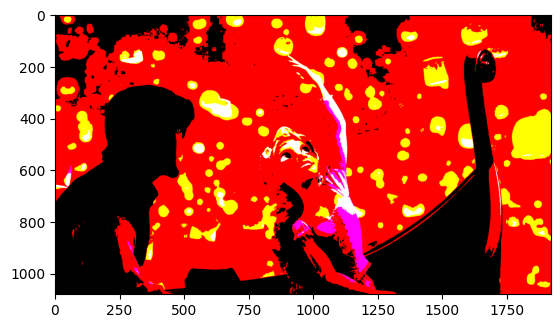

In [42]:
xbin = ((x > 100) * 255).astype(np.uint8)
# Why the image is not in gray ???
plt.imshow(xbin, cmap="gray")

#### As we binarize each channel separately, and then visualize them together, we do not get the black and white image. However, we still can plot each channel separately and see that they are binarized.

Text(0.5, 1.0, 'Binarized blue channel')

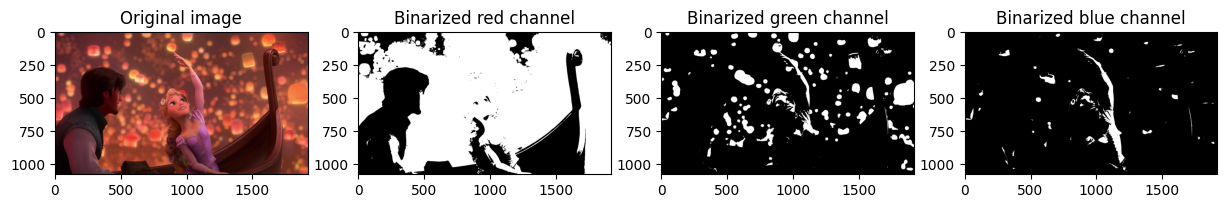

In [43]:
fig, axs = plt.subplots(1, 4, figsize=(15, 5))
axs[0].imshow(x)
axs[0].set_title("Original image")
axs[1].imshow(xbin[:, :, 0], cmap="gray")
axs[1].set_title("Binarized red channel")
axs[2].imshow(xbin[:, :, 1], cmap="gray")
axs[2].set_title("Binarized green channel")
axs[3].imshow(xbin[:, :, 2], cmap="gray")
axs[3].set_title("Binarized blue channel")

#### Besides of implementing this functions from scratch you can benefit from using libraries like [OpenCV](https://docs.opencv.org/3.4/d7/d4d/tutorial_py_thresholding.html) and [Scikit-Image](https://scikit-image.org/docs/stable/auto_examples/applications/plot_thresholding_guide.html).

#### Implement the binarization using methods from OpenCV. Before applying the binarization, convert the image to grayscale.

In [44]:
def binarize_image_opencv(x, t):
    """
    The function binarizes the image using the threshold t and OpenCV cv2.threshold method.

    Args:
        x : image
        t : threshold value
    """
    # YOUR CODE HERE
    xbin = cv2.cvtColor(x, cv2.COLOR_RGB2GRAY)
    _, xbin = cv2.threshold(xbin, t, 255, cv2.THRESH_BINARY)
    return xbin

In [45]:
assert binarize_image_opencv(np.ones((10, 10, 3), dtype=np.uint8), 1).sum() == 0

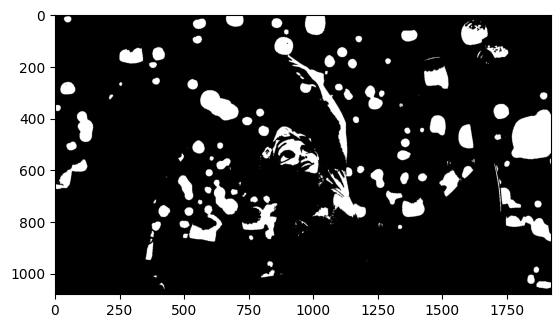

In [46]:
plt.imshow(binarize_image_opencv(x, 128), cmap="gray")

Looking at the methods from Scikit-Image library you can see that there are multiple ways to binarize the image.  
The actual difference between them lies in the way the threshold is calculated.  
Most of the times we cannot use the static threshold for all images. That's why these methods exist

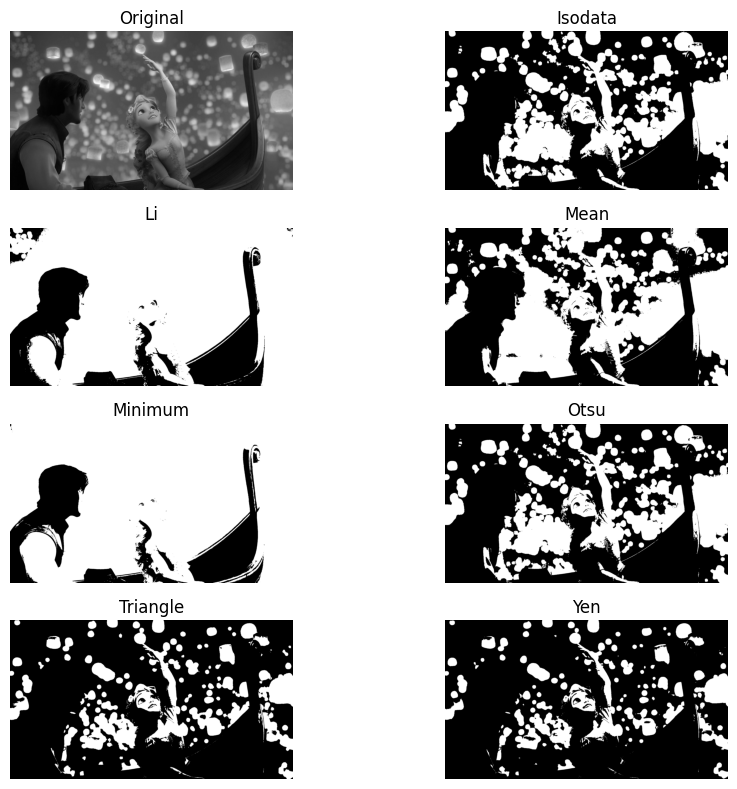

In [47]:
from skimage.filters import try_all_threshold

g = cv2.cvtColor(x, cv2.COLOR_RGB2GRAY)
fig, ax = try_all_threshold(g, figsize=(10, 8), verbose=False)
plt.show()

---
## Part F, convolution, filtering and kernels(2 points)


#### 1. Convolution
Convolution is a mathematical operation used to extract features from an image. It involves sliding a kernel (or filter) over the image and computing a weighted sum of pixel values.

- **Process**: For each position of the kernel over the image, multiply the values of the kernel with the corresponding underlying image pixel values, sum all these products, and write the sum into the corresponding pixel of the output image.
- **Applications**: Used for blurring, sharpening, edge detection, noise reduction, and more.
- **Example**: Sliding a 3x3 kernel over a 5x5 image, performing the weighted sum, and creating a new image.

#### 2. Filtering
Filtering in image processing modifies or enhances an image, typically by applying a convolution with a specific kernel.

- **Types of Filters**:
  - **Low-pass filters (Blurring)**: Allow low-frequency signals and smooth out high-frequency signals (like noise). Example: Gaussian blur.
  - **High-pass filters (Edge detection)**: Enhance high-frequency signals, useful for finding edges in images. Example: Sobel filter.
- **Applications**: Image enhancement, noise reduction, edge detection, and more.
- **Example**: Applying a Gaussian blur filter to smooth out sharp edges and reduce detail.

#### 3. Kernels
A kernel, or filter, is a small matrix used to apply effects like blurring, sharpening, and edge detection. It defines the weight or intensity given to neighboring pixels during convolution.

- **Characteristics**:
  - **Size**: Common sizes include 3x3, 5x5, and 7x7.
  - **Shape**: The values within a kernel determine its function.
- **Examples**:
  - **Box Blur Kernel**:
    ```
    1/9 1/9 1/9
    1/9 1/9 1/9
    1/9 1/9 1/9
    ```
  - **Edge Detection Kernel**:
    ```
    -1 -1 -1
    -1  8 -1
    -1 -1 -1
    ```

For this part we will use Scikit-Image library as it is the most suited for this task and functionally rich. Let's start with a simple example below.

Text(0.5, 1.0, 'Kernel3')

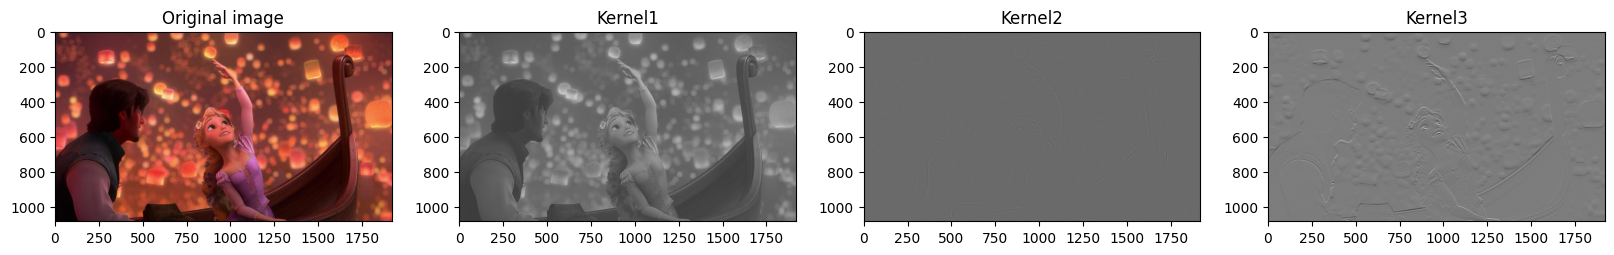

In [48]:
from scipy.ndimage import convolve
from skimage import filters, util


def apply_convolution(x, kernel):
    return convolve(x, kernel)


kernel1 = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
kernel2 = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])
kernel3 = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])

g = rgb2gray(x)

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs[0].imshow(x, cmap="gray")
axs[0].set_title("Original image")
axs[1].imshow(apply_convolution(g, kernel1), cmap="gray")
axs[1].set_title("Kernel1")
axs[2].imshow(apply_convolution(g, kernel2), cmap="gray")
axs[2].set_title("Kernel2")
axs[3].imshow(apply_convolution(g, kernel3), cmap="gray")
axs[3].set_title("Kernel3")

#### Now implement the following functions using Scikit-Image library:
1. Gaussian blur
2. Sharpen filter, which uses Gaussian blur as a base (unsharp_image = original_image - blurred_image)
3. Sobel filter
4. Median filter
5. Filter with identity kernel

In [61]:
def blur_image(x, sigma):
    # YOUR CODE HERE
    return filters.gaussian(x, sigma=sigma)

def sharpen_image(x, sigma):
    blurred = blur_image(x, sigma)
    # YOUR CODE HERE
    return np.clip(x + (x - blurred), 0, 1)

def apply_sobel_filter(x):
    # YOUR CODE HERE
    return filters.sobel(x)

def apply_median_filter(x):
    # YOUR CODE HERE
    return filters.median(x)


def apply_identity_kernel(x):
    # YOUR CODE HERE
    kernel = np.identity(3)
    return apply_convolution(x, kernel)

In [62]:
def plot_images(original, processed, title):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(processed, cmap='gray')
    plt.title(title)
    plt.axis('off')

    plt.show()

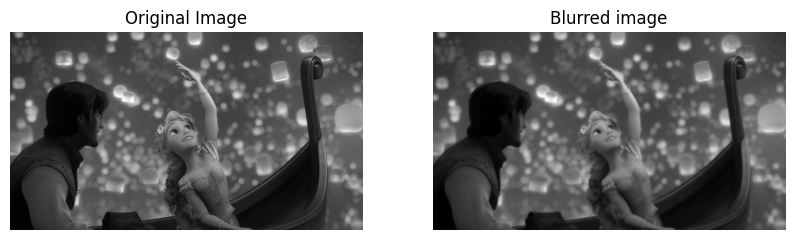

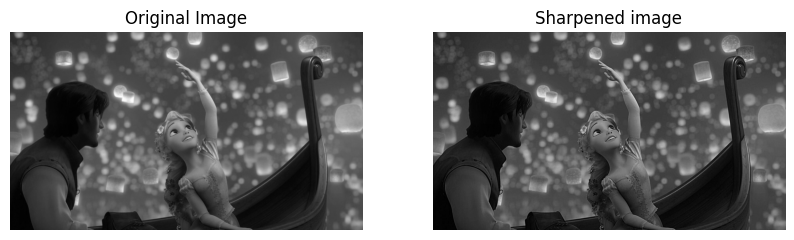

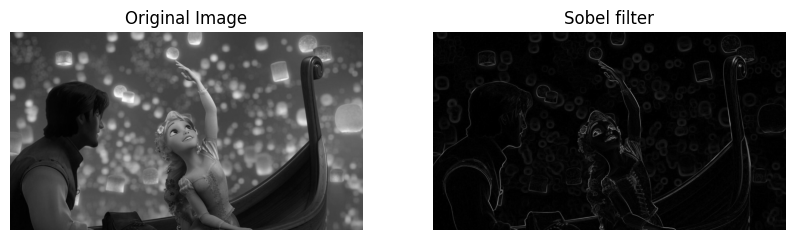

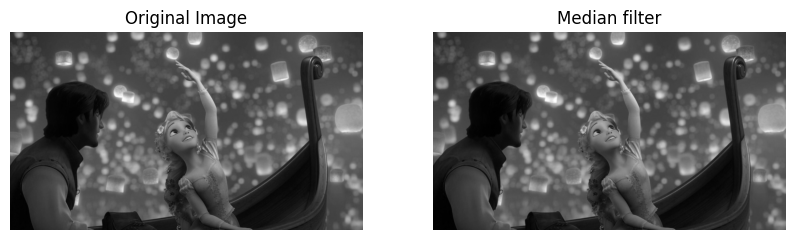

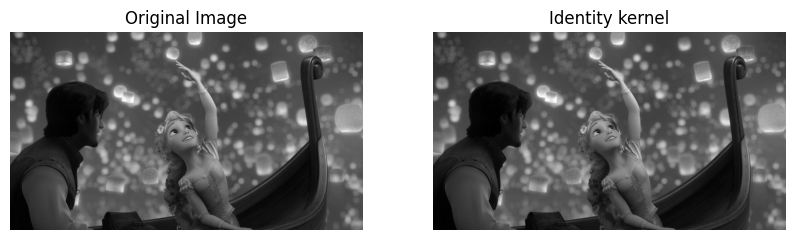

In [63]:
plot_images(g, blur_image(g, 3), "Blurred image")
plot_images(g, sharpen_image(g, 3), "Sharpened image")
plot_images(g, apply_sobel_filter(g), "Sobel filter")
plot_images(g, apply_median_filter(g), "Median filter")
plot_images(g, apply_identity_kernel(g), "Identity kernel")